## Aplicando modelos, escolhendo um e treinando a base

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
)

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from Apoio.auxiliares import dataframe_coeficientes
from Apoio.config import DADOS_TRATADOS
from Apoio.graficos import plot_comparar_metricas_modelos, plot_coeficientes
from Apoio.models_rus import RANDOM_STATE
from Apoio.models_rus import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V23,V24,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.403993,0.251412,-0.018307,-0.110474,0.066928,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.145783,-0.069083,-0.225775,0.101288,-0.339846,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.232622,-0.208038,-0.108300,-0.190321,-1.175575,-0.221929,0.062723,0.061458,123.50,0
3,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.803487,0.408542,-0.009431,-0.137458,0.141267,0.502292,0.219422,0.215153,69.99,0
4,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.033194,0.084968,-0.208254,-0.026398,-0.371427,0.105915,0.253844,0.081080,3.67,0


In [3]:
coluna_min_max = ["Time"]

coluna_power_transformer = ["Amount"]

coluna_target = ["Class"]

coluna_robust_scaler = [
    coluna for coluna in df.columns
    if coluna not in (coluna_min_max + coluna_power_transformer + coluna_target)
]

In [4]:
coluna_robust_scaler

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V23',
 'V24',
 'V26',
 'V27',
 'V28']

In [5]:
X = df.drop(columns=coluna_target)
y = df[coluna_target].values.ravel()

In [6]:
preprocessamento = ColumnTransformer(
    transformers = [
        ("min_max", MinMaxScaler(), coluna_min_max),
        ("robust", RobustScaler(), coluna_robust_scaler),
        ("power_transform", PowerTransformer(), coluna_power_transformer)
    ]
)

In [7]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression(class_weight="balanced")
    },

    "DecisionTreeClassifier": {
       "preprocessor": None,
        "classificador": DecisionTreeClassifier(class_weight="balanced")
    },

    "LGBMClassifier": {
       "preprocessor": None,
        "classificador": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    },

    "XGBClassifier": {
       "preprocessor": None,
        "classificador": XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    },

    "SVC": {
        "preprocessor": preprocessamento,
        "classificador": SVC(class_weight="balanced", cache_size=1000),
    },

    "KNeighborsClassifier": {
       "preprocessor": preprocessamento,
        "classificador": KNeighborsClassifier()
    }
}

In [8]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [9]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)
df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.15432,0.079191,0.498402,0.458461,0.003176,0.001594,0.418367,0.510399,0.001951,0.233511
1,DummyClassifier,0.238185,0.151273,0.498461,0.52469,0.004179,0.002097,0.55102,0.497276,0.001899,0.389457
2,DummyClassifier,0.134147,0.060232,0.500058,0.515306,0.004037,0.002026,0.530612,0.479455,0.001838,0.19438
3,DummyClassifier,0.108374,0.058233,0.499454,0.527451,0.004264,0.00214,0.555556,0.469933,0.001827,0.166607
4,DummyClassifier,0.112388,0.101794,0.504229,0.50968,0.003993,0.002004,0.515152,0.526484,0.002042,0.214182
5,LogisticRegression,1.937025,0.2166,0.972562,0.935332,0.111111,0.059219,0.897959,0.984227,0.52356,2.153625
6,LogisticRegression,1.384489,0.218341,0.97151,0.960266,0.112864,0.06,0.94898,0.991035,0.687396,1.602829
7,LogisticRegression,1.124578,0.206613,0.972445,0.95055,0.114035,0.060748,0.928571,0.97567,0.754307,1.331191
8,LogisticRegression,1.400565,0.216598,0.976265,0.942743,0.128755,0.069284,0.909091,0.980751,0.516566,1.617163
9,LogisticRegression,1.162741,0.259011,0.978233,0.963892,0.144061,0.077944,0.949495,0.983963,0.689226,1.421752


In [10]:
df_resultados.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.149483,0.090145,0.500121,0.507118,0.00393,0.001972,0.514141,0.49671,0.001911,0.239627
DecisionTreeClassifier,0.187719,0.085303,0.916572,0.916635,0.0413,0.021138,0.916698,0.916635,0.019535,0.273022
KNeighborsClassifier,1.775061,9.423321,0.975279,0.936868,0.125031,0.067304,0.89831,0.973087,0.259924,11.198382
LogisticRegression,1.401879,0.223433,0.974203,0.950557,0.122165,0.065439,0.926819,0.983129,0.634211,1.625312
SVC,1.45868,5.518702,0.984632,0.929415,0.184334,0.103549,0.873985,0.985339,0.729458,6.977382
LGBMClassifier,0.376074,0.449244,0.973459,0.9522,0.120431,0.064477,0.93086,0.985891,0.738868,0.825318
XGBClassifier,0.382388,0.213575,0.968478,0.95275,0.10331,0.054705,0.936961,0.985594,0.764235,0.595963


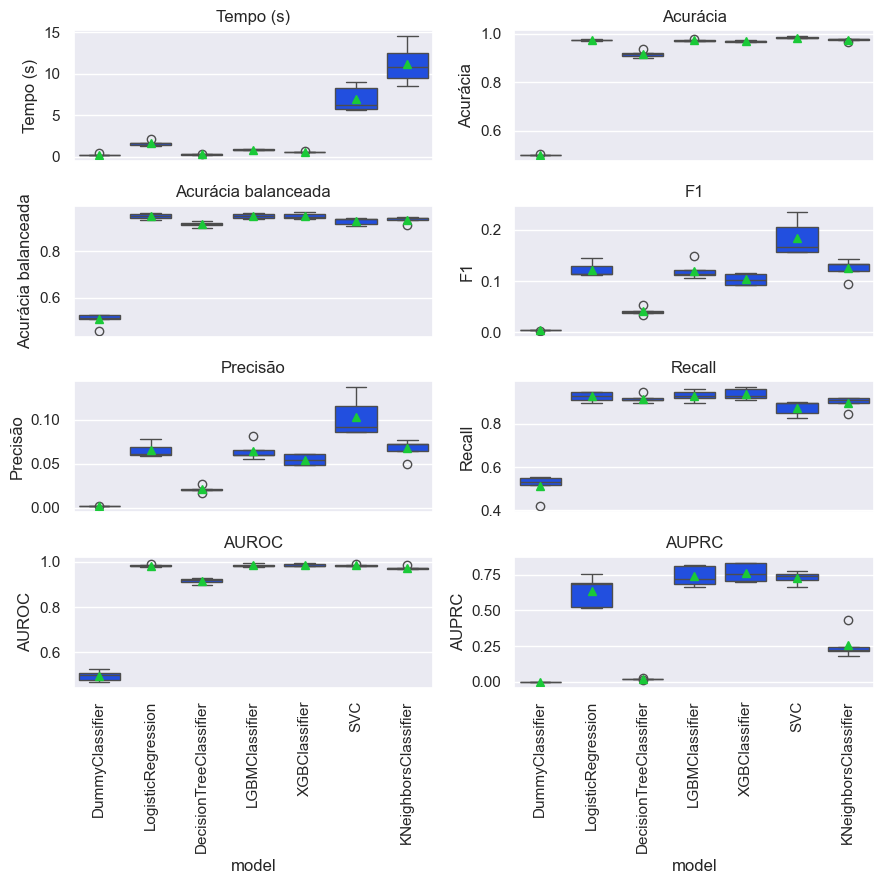

In [11]:
plot_comparar_metricas_modelos(df_resultados)

In [12]:
classificadores["XGBClassifier"]

{'preprocessor': None,
 'classificador': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=-1,
               num_parallel_tree=None, random_state=42, ...)}

In [13]:
treinar_e_validar_modelo_classificacao(X, y, kf, **classificadores["XGBClassifier"])

{'fit_time': array([0.58032942, 0.47343087, 0.3885715 , 0.4475944 , 0.30634975]),
 'score_time': array([0.27713323, 0.21155477, 0.27128005, 0.19176888, 0.28319836]),
 'test_accuracy': array([0.97340011, 0.96412425, 0.96505963, 0.96876218, 0.97104217]),
 'test_balanced_accuracy': array([0.9408441 , 0.96165869, 0.94685044, 0.94402496, 0.97037087]),
 'test_f1': array([0.11535969, 0.09265648, 0.0921519 , 0.10196078, 0.11442193]),
 'test_precision': array([0.0615917 , 0.04867944, 0.04848162, 0.0539739 , 0.06079797]),
 'test_recall': array([0.90816327, 0.95918367, 0.92857143, 0.91919192, 0.96969697]),
 'test_roc_auc': array([0.98112091, 0.98930711, 0.98074876, 0.98001275, 0.99678068]),
 'test_average_precision': array([0.7009782 , 0.75225609, 0.83117738, 0.70334119, 0.83342021])}

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, stratify=y)

In [15]:
clf = classificadores["XGBClassifier"]["classificador"]
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [16]:
perm_imp = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="average_precision")
ordem = perm_imp.importances_mean.argsort()

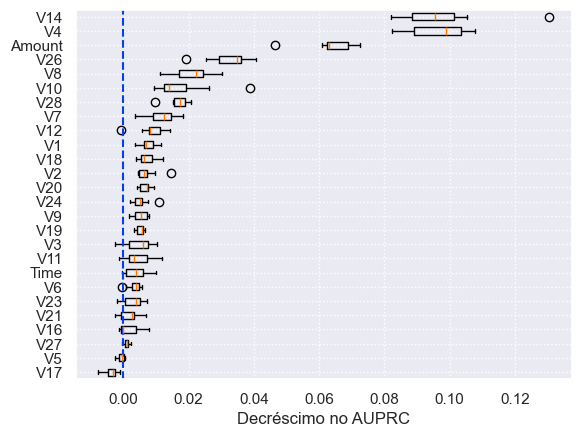

In [17]:
fig, ax = plt.subplots()

ax.boxplot(perm_imp.importances[ordem].T, vert=False, tick_labels=X.columns[ordem])
ax.axvline(x=0, linestyle="--")
ax.set_xlabel("Decréscimo no AUPRC")
ax.grid(True, linestyle=":")

plt.show()

In [18]:
perm_imp.importances_mean

array([ 0.0038711 ,  0.00746586,  0.00695732,  0.00471458,  0.09658715,
       -0.00066642,  0.00338244,  0.0120033 ,  0.02124057,  0.00531676,
        0.01763103,  0.00424987,  0.00865452,  0.09741375,  0.00176996,
       -0.00373591,  0.00713234,  0.00527935,  0.00659725,  0.00180054,
        0.00302102,  0.00532881,  0.03266309,  0.00100914,  0.01705667,
        0.06399492])

In [19]:
X.columns[perm_imp.importances_mean < 0.01]

Index(['Time', 'V1', 'V2', 'V3', 'V5', 'V6', 'V9', 'V11', 'V12', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V23', 'V24', 'V27'],
      dtype='object')

In [20]:
X = X.drop(columns=X.columns[perm_imp.importances_mean < 0.01])

X.columns

Index(['V4', 'V7', 'V8', 'V10', 'V14', 'V26', 'V28', 'Amount'], dtype='object')

In [21]:
treinar_e_validar_modelo_classificacao(X, y, kf, **classificadores["XGBClassifier"])

{'fit_time': array([0.37964892, 0.25838995, 0.2821095 , 0.20114803, 0.27464747]),
 'score_time': array([0.5448041 , 0.2034266 , 0.21352267, 0.18744588, 0.19672894]),
 'test_accuracy': array([0.96864526, 0.95239302, 0.95697248, 0.95749864, 0.96309143]),
 'test_balanced_accuracy': array([0.93846212, 0.95068957, 0.95298368, 0.94342304, 0.96134707]),
 'test_f1': array([0.09960828, 0.07074933, 0.07769424, 0.07780127, 0.09117083]),
 'test_precision': array([0.0526939 , 0.03674437, 0.04050523, 0.04060018, 0.04785894]),
 'test_recall': array([0.90816327, 0.94897959, 0.94897959, 0.92929293, 0.95959596]),
 'test_roc_auc': array([0.98357561, 0.98665269, 0.98755998, 0.98278251, 0.99327539]),
 'test_average_precision': array([0.69282232, 0.77979739, 0.7418834 , 0.67040329, 0.75365037])}

In [22]:
param_grid = {
    "clf__max_depth": [3, 6, 10],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0], 
    "clf__reg_lambda": [1, 2, 5],
    "clf__reg_alpha": [0, 0.5, 1],
}

In [24]:
clf = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)

In [25]:
grid_search = grid_search_cv_classificador(clf, param_grid, kf, None, refit_metric="average_precision")
grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sampler',
                                        RandomUnderSampler(random_state=42)),
                                       ('clf',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_me...
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'clf__colsample_bytree': [0.6, 0.8, 1.0],
                         'clf__max_depth': [3, 6, 10],
                         'clf__reg_alpha': [0, 0.5, 1],
                         'clf__reg_lambda': [1, 2, 5],
                         'clf__subsample': [0.6, 0.8, 1.0]},
             refit='average_precision',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [26]:
grid_search.fit(X, y)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sampler',
                                        RandomUnderSampler(random_state=42)),
                                       ('clf',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_me...
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'clf__colsample_bytree': [0.6, 0.8, 1.0],
                         'clf__max_depth': [3, 6, 10],
                         'clf__reg_alpha': [0, 0.5, 1],
                         'clf__reg_lambda': [1, 2, 5],
                         'clf__subsample': [0.6, 0.8, 1.0]},
             refit='average_precision',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [27]:
grid_search.best_params_

{'clf__colsample_bytree': 0.6,
 'clf__max_depth': 3,
 'clf__reg_alpha': 0,
 'clf__reg_lambda': 5,
 'clf__subsample': 1.0}

In [28]:
grid_search.best_score_

np.float64(0.7692786778559451)

In [29]:
grid_search.best_estimator_

Pipeline(steps=[('sampler', RandomUnderSampler(random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.6, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

In [30]:
lista_testes = [coluna for coluna in df_resultados.columns if coluna.startswith("test")]
mean_lista_teste = ["mean_" + coluna for coluna in lista_testes]

In [31]:
for coluna in mean_lista_teste:
    print(f"{coluna}: {grid_search.cv_results_[coluna][grid_search.best_index_]}")

mean_test_accuracy: 0.96305635669187
mean_test_balanced_accuracy: 0.9469991907117358
mean_test_f1: 0.09007850874052839
mean_test_precision: 0.04739761356269136
mean_test_recall: 0.930880230880231
mean_test_roc_auc: 0.9868163940312433
mean_test_average_precision: 0.7692786778559451


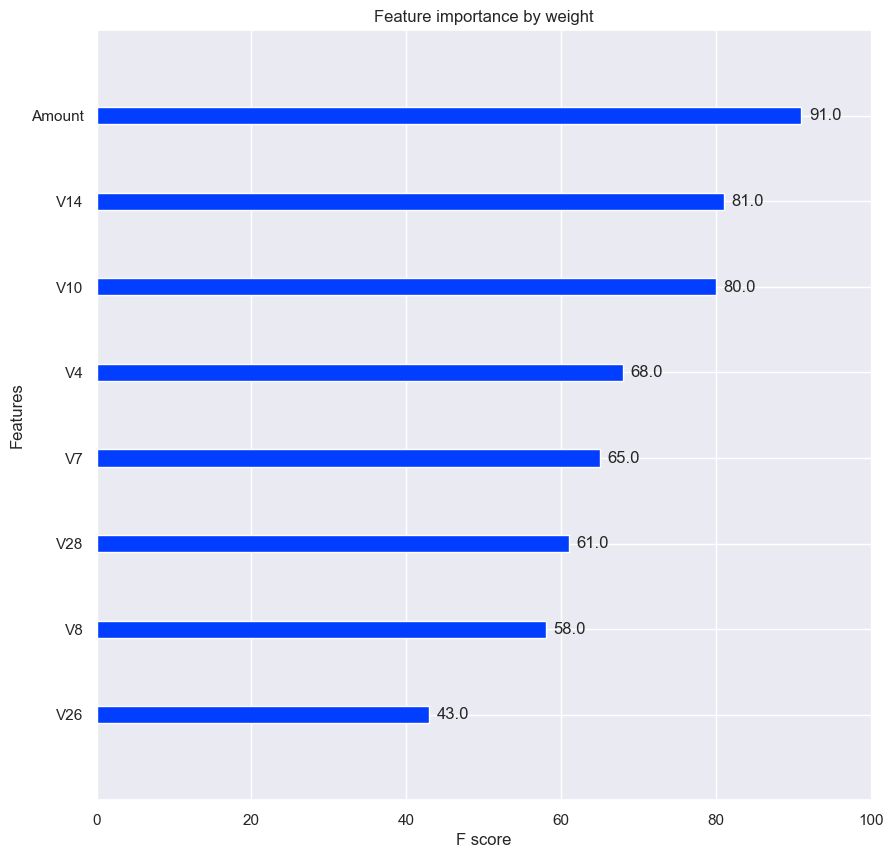

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_importance(grid_search.best_estimator_["clf"], ax=ax, importance_type="weight", title="Feature importance by weight")

plt.show()

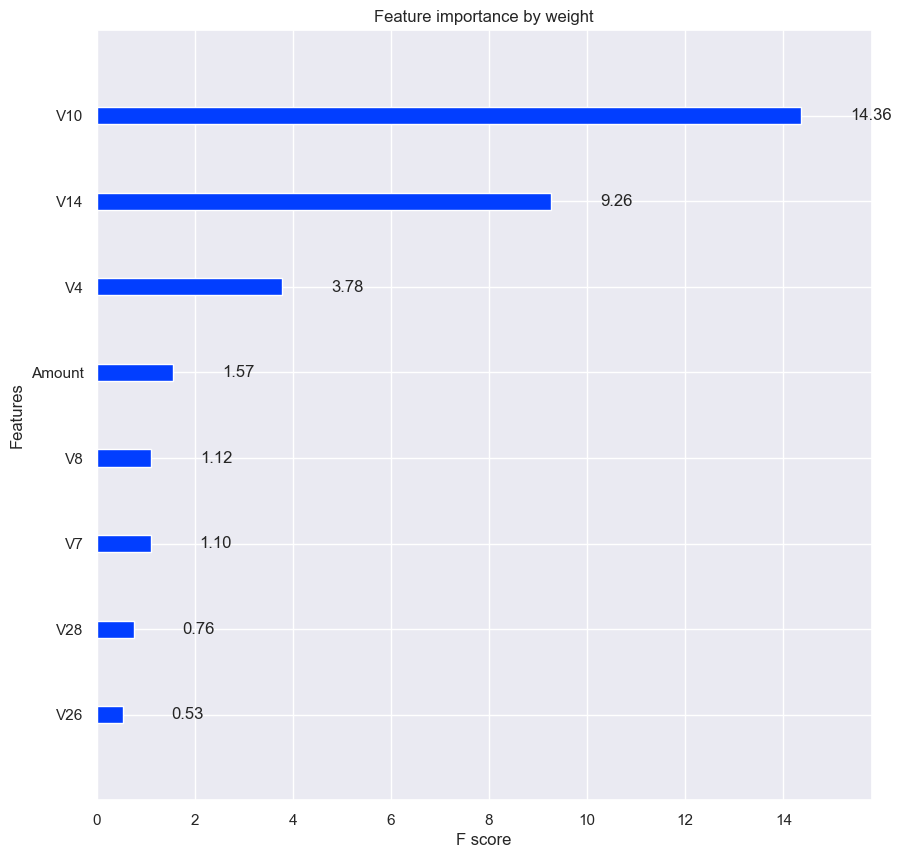

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_importance(grid_search.best_estimator_["clf"], ax=ax, importance_type="gain", title="Feature importance by weight", values_format="{v:.2f}")

plt.show()